# Gender Bias Exploration — XGBoost

**Model rationale for ADNI data:**  
XGBoost is a natural choice for ADNI's tabular clinical data: handles missing values natively, captures non-linear feature interactions (e.g., genotype × cognitive score), provides built-in feature importance, and performs well with limited sample sizes (n=757). It's widely used in clinical prediction tasks.

Hyperparameters: n_estimators=200, max_depth=4, learning_rate=0.1, subsample=0.8.

**6 debiasing methods × 2 imbalance modes = 12 configurations.**

In [1]:
%matplotlib inline
from exploration_utils import *
from IPython.display import display, Markdown

I0000 00:00:1781880778.647314   39594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781880778.647792   39594 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781880778.686049   39594 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781880779.489226   39594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
df = load_adni_data()
print('Original shape:', df.shape)
df = drop_metadata(df)
print('After dropping metadata:', df.shape)
display(df.head(2))

Original shape: (757, 147)
After dropping metadata: (757, 129)


,DIAGNOSIS,Sex,age,DXNODEP,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,...,RIGHT_BA36_VOL,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS
0,0,0,57.9,0,0,0,0,0,0,0,...,0.099781,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0
1,0,0,66.4,0,0,0,0,0,0,0,...,0.122244,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0


In [3]:
dataset = make_bld(df)
dataset_train, dataset_val = split_dataset(dataset)
print(f'Train: {dataset_train.features.shape}, Val: {dataset_val.features.shape}')

m_train = BinaryLabelDatasetMetric(dataset_train,
    unprivileged_groups=UNPRIVILEGED_GROUPS, privileged_groups=PRIVILEGED_GROUPS)
m_val = BinaryLabelDatasetMetric(dataset_val,
    unprivileged_groups=UNPRIVILEGED_GROUPS, privileged_groups=PRIVILEGED_GROUPS)
print(f'Training disparate impact = {m_train.disparate_impact():.4f}')
print(f'Validation disparate impact = {m_val.disparate_impact():.4f}')

Train: (499, 128), Val: (258, 128)
Training disparate impact = 0.8232
Validation disparate impact = 1.1675


---
## Baseline (no debiasing)

**Rationale:** Baseline XGBoost without any fairness intervention. Establishes reference for bias metrics.

In [4]:
res_xgb_base_smote = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='None')


  XGB | None | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.1783
  Metrics:
  Balanced accuracy = 0.8709
  Average odds difference = -0.0471
  Disparate impact = 1.1220
  Equal opportunity difference = -0.1341
  Statistical parity difference = 0.0251
  Theil index = 0.0662

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQGAME > 0.98: T=-10.252, p=0.000018

  No significant features (females, baseline)

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQGAME > 0.98: T=-10.252, p=0.000018

  No significant features (females, debiased)


In [5]:
res_xgb_base_cw = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='None')


  XGB | None | class_weight

  --- Baseline model ---
  Threshold: 0.0595
  Metrics:
  Balanced accuracy = 0.8696
  Average odds difference = -0.0831
  Disparate impact = 0.9529
  Equal opportunity difference = -0.1633
  Statistical parity difference = -0.0144
  Theil index = 0.0644

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQSHOP > 0.07: T=16.150, p=0.000001
    FAQTOTAL > 0.41: T=11.649, p=0.000008
    FAQREM > 0.67: T=8.727, p=0.000052

  Significant (females, baseline):
    WORD2DL_x <= -1.21: T=21.186, p=0.000029
    FAQSHOP > 0.07: T=21.389, p=0.000028
    FAQTOTAL > 0.41: T=19.803, p=0.000038

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQSHOP > 0.07: T=16.150, p=0.000001
    FAQTOTAL > 0.41: T=11.649, p=0.000008
    FAQREM > 0.67: T=8.727, p=0.000052

  Significant (females, debiased):
    WORD2DL_x <= -1.21: T=21.186, p=0.000029
    FAQSHOP > 0.07: T=21.389, p=0.000028
    FAQTOTAL > 0.41: T=

---
## DisparateImpactRemover (DIR)

**Rationale:** DIR removes the rank correlation between Sex and all features. For tree-based models like XGBoost, this is particularly interesting because DIR's percentile-based redistribution interacts with tree splits differently than with linear decision boundaries.

In [6]:
res_xgb_dir_smote = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='DIR')


  XGB | DIR | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.1783
  Metrics:
  Balanced accuracy = 0.8709
  Average odds difference = -0.0471
  Disparate impact = 1.1220
  Equal opportunity difference = -0.1341
  Statistical parity difference = 0.0251
  Theil index = 0.0662
  --- Debiased model (DIR) ---
  Threshold: 0.1090
  Metrics:
  Balanced accuracy = 0.8899
  Average odds difference = -0.0483
  Disparate impact = 1.0988
  Equal opportunity difference = -0.1321
  Statistical parity difference = 0.0238
  Theil index = 0.0563

  Cases improved by debiasing: 5
     y_true  pred_orig  pred_deb     Sex
34      1.0        0.0       1.0    Male
127     1.0        0.0       1.0  Female
152     1.0        0.0       1.0  Female
187     1.0        0.0       1.0    Male
234     0.0        1.0       0.0  Female

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQGAME > 0.98: T=-10.382, p=0.000017

  No significant features (females, baseline

In [7]:
res_xgb_dir_cw = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='DIR')


  XGB | DIR | class_weight

  --- Baseline model ---
  Threshold: 0.0595
  Metrics:
  Balanced accuracy = 0.8696
  Average odds difference = -0.0831
  Disparate impact = 0.9529
  Equal opportunity difference = -0.1633
  Statistical parity difference = -0.0144
  Theil index = 0.0644
  --- Debiased model (DIR) ---
  Threshold: 0.0793
  Metrics:
  Balanced accuracy = 0.8796
  Average odds difference = -0.1405
  Disparate impact = 0.8230
  Equal opportunity difference = -0.2591
  Statistical parity difference = -0.0515
  Theil index = 0.0610

  Cases improved by debiasing: 12
     y_true  pred_orig  pred_deb     Sex
35      0.0        1.0       0.0    Male
40      0.0        1.0       0.0    Male
81      0.0        1.0       0.0  Female
154     0.0        1.0       0.0  Female
172     0.0        1.0       0.0    Male
176     0.0        1.0       0.0    Male
177     0.0        1.0       0.0    Male
204     0.0        1.0       0.0  Female
226     1.0        0.0       1.0    Male
234     0.

---
## Reweighing

**Rationale:** Reweighing adjusts sample weights to achieve demographic parity. XGBoost natively supports sample weights, making this a natural fit.

In [8]:
res_xgb_rw_smote = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='Reweighing')


  XGB | Reweighing | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.1783
  Metrics:
  Balanced accuracy = 0.8709
  Average odds difference = -0.0471
  Disparate impact = 1.1220
  Equal opportunity difference = -0.1341
  Statistical parity difference = 0.0251
  Theil index = 0.0662
  --- Debiased model (Reweighing) ---
  Threshold: 0.1387
  Metrics:
  Balanced accuracy = 0.8712
  Average odds difference = -0.0344
  Disparate impact = 1.1274
  Equal opportunity difference = -0.1018
  Statistical parity difference = 0.0280
  Theil index = 0.0661

  Cases improved by debiasing: 1
     y_true  pred_orig  pred_deb     Sex
152     1.0        0.0       1.0  Female

  --- T-tests (baseline) ---

  No significant features (males, baseline)

  No significant features (females, baseline)

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQGAME > 0.98: T=-10.130, p=0.000020

  No significant features (females, debiased)


In [9]:
res_xgb_rw_cw = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='Reweighing')


  XGB | Reweighing | class_weight

  --- Baseline model ---
  Threshold: 0.0595
  Metrics:
  Balanced accuracy = 0.8696
  Average odds difference = -0.0831
  Disparate impact = 0.9529
  Equal opportunity difference = -0.1633
  Statistical parity difference = -0.0144
  Theil index = 0.0644
  --- Debiased model (Reweighing) ---
  Threshold: 0.0595
  Metrics:
  Balanced accuracy = 0.8696
  Average odds difference = -0.0727
  Disparate impact = 1.0043
  Equal opportunity difference = -0.1633
  Statistical parity difference = 0.0013
  Theil index = 0.0644

  Cases improved by debiasing: 4
     y_true  pred_orig  pred_deb     Sex
1       0.0        1.0       0.0    Male
204     0.0        1.0       0.0  Female
226     1.0        0.0       1.0    Male
251     0.0        1.0       0.0    Male

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQTOTAL > 0.41: T=14.286, p=0.000002
    FAQSHOP > 0.07: T=19.986, p=0.000000
    FAQREM > 0.67: T=8.208, p=0.000077
    FAQMEAL > 0.1

---
## AdversarialDebiasing

**Rationale:** AdversarialDebiasing modifies features to be sex-agnostic before training. For XGBoost, this tests whether removing gender-correlated information from features helps tree-based splits become fairer.

In [10]:
res_xgb_ad_smote = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='AdversarialDebiasing')


  XGB | AdversarialDebiasing | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.1783
  Metrics:
  Balanced accuracy = 0.8709
  Average odds difference = -0.0471
  Disparate impact = 1.1220
  Equal opportunity difference = -0.1341
  Statistical parity difference = 0.0251
  Theil index = 0.0662
Instructions for updating:
non-resource variables are not supported in the long term


Instructions for updating:
non-resource variables are not supported in the long term
E0000 00:00:1781880854.986799   39594 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1781880855.259533   39594 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


epoch 0; iter: 0; batch classifier loss: 2.980596; batch adversarial loss: 0.744365
epoch 1; iter: 0; batch classifier loss: 1.894905; batch adversarial loss: 0.814140
epoch 2; iter: 0; batch classifier loss: 0.943890; batch adversarial loss: 0.694460
epoch 3; iter: 0; batch classifier loss: 1.167397; batch adversarial loss: 0.685279
epoch 4; iter: 0; batch classifier loss: 0.863835; batch adversarial loss: 0.693011
epoch 5; iter: 0; batch classifier loss: 0.859303; batch adversarial loss: 0.675584
epoch 6; iter: 0; batch classifier loss: 0.908263; batch adversarial loss: 0.720042
epoch 7; iter: 0; batch classifier loss: 0.664316; batch adversarial loss: 0.722251
epoch 8; iter: 0; batch classifier loss: 0.538644; batch adversarial loss: 0.667455
epoch 9; iter: 0; batch classifier loss: 0.639653; batch adversarial loss: 0.691917
epoch 10; iter: 0; batch classifier loss: 0.520420; batch adversarial loss: 0.696687
epoch 11; iter: 0; batch classifier loss: 0.507252; batch adversarial loss:

In [11]:
res_xgb_ad_cw = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='AdversarialDebiasing')


  XGB | AdversarialDebiasing | class_weight

  --- Baseline model ---
  Threshold: 0.0595
  Metrics:
  Balanced accuracy = 0.8696
  Average odds difference = -0.0831
  Disparate impact = 0.9529
  Equal opportunity difference = -0.1633
  Statistical parity difference = -0.0144
  Theil index = 0.0644
epoch 0; iter: 0; batch classifier loss: 3.056844; batch adversarial loss: 0.776101
epoch 1; iter: 0; batch classifier loss: 1.399364; batch adversarial loss: 0.736132
epoch 2; iter: 0; batch classifier loss: 1.502724; batch adversarial loss: 0.696930
epoch 3; iter: 0; batch classifier loss: 1.190660; batch adversarial loss: 0.698365
epoch 4; iter: 0; batch classifier loss: 0.793859; batch adversarial loss: 0.726479
epoch 5; iter: 0; batch classifier loss: 0.906635; batch adversarial loss: 0.686503
epoch 6; iter: 0; batch classifier loss: 1.139508; batch adversarial loss: 0.728298
epoch 7; iter: 0; batch classifier loss: 0.902096; batch adversarial loss: 0.712188
epoch 8; iter: 0; batch cla

---
## PrejudiceRemover

**Rationale:** PrejudiceRemover adds fairness regularization. For gradient-boosted trees, this tests whether penalizing dependence on Sex during feature transformation improves fairness metrics.

In [12]:
res_xgb_pr_smote = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='PrejudiceRemover')


  XGB | PrejudiceRemover | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.1783
  Metrics:
  Balanced accuracy = 0.8709
  Average odds difference = -0.0471
  Disparate impact = 1.1220
  Equal opportunity difference = -0.1341
  Statistical parity difference = 0.0251
  Theil index = 0.0662


/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn

  --- Debiased model (PrejudiceRemover) ---
  Threshold: 0.1783
  Metrics:
  Balanced accuracy = 0.8709
  Average odds difference = -0.0471
  Disparate impact = 1.1220
  Equal opportunity difference = -0.1341
  Statistical parity difference = 0.0251
  Theil index = 0.0662

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQGAME > 0.98: T=-11.397, p=0.000009

  No significant features (females, baseline)

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQGAME > 0.98: T=-12.938, p=0.000004

  No significant features (females, debiased)


In [13]:
res_xgb_pr_cw = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='PrejudiceRemover')


  XGB | PrejudiceRemover | class_weight

  --- Baseline model ---


  Threshold: 0.0595
  Metrics:
  Balanced accuracy = 0.8696
  Average odds difference = -0.0831
  Disparate impact = 0.9529
  Equal opportunity difference = -0.1633
  Statistical parity difference = -0.0144
  Theil index = 0.0644


/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn

  --- Debiased model (PrejudiceRemover) ---
  Threshold: 0.0595
  Metrics:
  Balanced accuracy = 0.8696
  Average odds difference = -0.0831
  Disparate impact = 0.9529
  Equal opportunity difference = -0.1633
  Statistical parity difference = -0.0144
  Theil index = 0.0644

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQREM > 0.67: T=9.666, p=0.000027
    FAQSHOP > 0.07: T=12.558, p=0.000005
    FAQMEAL > 0.11: T=8.435, p=0.000065
    FAQTOTAL > 0.41: T=9.022, p=0.000042

  Significant (females, baseline):
    WORD2DL_x <= -1.21: T=18.102, p=0.000055

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQSHOP > 0.07: T=25.552, p=0.000000
    FAQTOTAL > 0.41: T=20.381, p=0.000000
    FAQREM > 0.67: T=9.662, p=0.000027

  Significant (females, debiased):
    WORD2DL_x <= -1.21: T=33.108, p=0.000005


---
## RejectOptionClassifier (post-processing)

**Rationale:** Post-processing adjusts XGBoost's probability threshold in critical regions. Tests whether simple threshold adjustment suffices for tree-based models.

In [14]:
res_xgb_ro_smote = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='RejectOption')


  XGB | RejectOption | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.1783
  Metrics:
  Balanced accuracy = 0.8709
  Average odds difference = -0.0471
  Disparate impact = 1.1220
  Equal opportunity difference = -0.1341
  Statistical parity difference = 0.0251
  Theil index = 0.0662
  --- Debiased model (RejectOption) ---
  Metrics:
  Balanced accuracy = 0.8709
  Average odds difference = -0.0471
  Disparate impact = 1.1220
  Equal opportunity difference = -0.1341
  Statistical parity difference = 0.0251
  Theil index = 0.0662

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQGAME > 0.98: T=-8.958, p=0.000044

  No significant features (females, baseline)

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQGAME > 0.98: T=-20.217, p=0.000000

  No significant features (females, debiased)


In [15]:
res_xgb_ro_cw = run_comparison(
    'xgb', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='RejectOption')


  XGB | RejectOption | class_weight

  --- Baseline model ---


  Threshold: 0.0595
  Metrics:
  Balanced accuracy = 0.8696
  Average odds difference = -0.0831
  Disparate impact = 0.9529
  Equal opportunity difference = -0.1633
  Statistical parity difference = -0.0144
  Theil index = 0.0644
  --- Debiased model (RejectOption) ---
  Metrics:
  Balanced accuracy = 0.8759
  Average odds difference = -0.0107
  Disparate impact = 1.1313
  Equal opportunity difference = -0.0655
  Statistical parity difference = 0.0456
  Theil index = 0.0552

  Cases improved by debiasing: 5
     y_true  pred_orig  pred_deb     Sex
66      1.0        0.0       1.0  Female
185     1.0        0.0       1.0  Female
195     1.0        0.0       1.0  Female
226     1.0        0.0       1.0    Male
242     1.0        0.0       1.0  Female

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQSHOP > 0.07: T=17.753, p=0.000000
    FAQREM > 0.67: T=13.432, p=0.000003
    FAQMEAL > 0.11: T=8.299, p=0.000072
    FAQTOTAL > 0.41: T=9.920, p=0.000023

  Significant 

---
## Comparison table

In [16]:
configs = [
    ('Baseline', 'SMOTE', res_xgb_base_smote),
    ('Baseline', 'class_weight', res_xgb_base_cw),
    ('DIR', 'SMOTE', res_xgb_dir_smote),
    ('DIR', 'class_weight', res_xgb_dir_cw),
    ('Reweighing', 'SMOTE', res_xgb_rw_smote),
    ('Reweighing', 'class_weight', res_xgb_rw_cw),
    ('AdversarialDebiasing', 'SMOTE', res_xgb_ad_smote),
    ('AdversarialDebiasing', 'class_weight', res_xgb_ad_cw),
    ('PrejudiceRemover', 'SMOTE', res_xgb_pr_smote),
    ('PrejudiceRemover', 'class_weight', res_xgb_pr_cw),
    ('RejectOption', 'SMOTE', res_xgb_ro_smote),
    ('RejectOption', 'class_weight', res_xgb_ro_cw),
]

rows = [results_row(d, i, r) for d, i, r in configs]
df_xgb = pd.DataFrame(rows)
print('=== XGBoost — Complete Results ===')
display(df_xgb.round(4))
save_results('XGBoost', df_xgb)

=== XGBoost — Complete Results ===


,Debiasing,Imbalance,BA (base),BA (deb),DI (base),DI (deb),AOD (base),AOD (deb),SPD (base),SPD (deb),Theil (base),Theil (deb),EOD (base),EOD (deb),Improved
0,Baseline,SMOTE,0.8709,0.8709,1.1220,1.1220,-0.0471,-0.0471,0.0251,0.0251,0.0662,0.0662,-0.1341,-0.1341,0
1,Baseline,class_weight,0.8696,0.8696,0.9529,0.9529,-0.0831,-0.0831,-0.0144,-0.0144,0.0644,0.0644,-0.1633,-0.1633,0
2,DIR,SMOTE,0.8709,0.8899,1.1220,1.0988,-0.0471,-0.0483,0.0251,0.0238,0.0662,0.0563,-0.1341,-0.1321,5
3,DIR,class_weight,0.8696,0.8796,0.9529,0.8230,-0.0831,-0.1405,-0.0144,-0.0515,0.0644,0.0610,-0.1633,-0.2591,12
4,Reweighing,SMOTE,0.8709,0.8712,1.1220,1.1274,-0.0471,-0.0344,0.0251,0.0280,0.0662,0.0661,-0.1341,-0.1018,1
5,Reweighing,class_weight,0.8696,0.8696,0.9529,1.0043,-0.0831,-0.0727,-0.0144,0.0013,0.0644,0.0644,-0.1633,-0.1633,4
6,AdversarialDebiasing,SMOTE,0.8709,0.8709,1.1220,1.1220,-0.0471,-0.0471,0.0251,0.0251,0.0662,0.0662,-0.1341,-0.1341,0
7,AdversarialDebiasing,class_weight,0.8696,0.8696,0.9529,0.9529,-0.0831,-0.0831,-0.0144,-0.0144,0.0644,0.0644,-0.1633,-0.1633,0
8,PrejudiceRemover,SMOTE,0.8709,0.8709,1.1220,1.1220,-0.0471,-0.0471,0.0251,0.0251,0.0662,0.0662,-0.1341,-0.1341,0
9,PrejudiceRemover,class_weight,0.8696,0.8696,0.9529,0.9529,-0.0831,-0.0831,-0.0144,-0.0144,0.0644,0.0644,-0.1633,-0.1633,0


Saved to ../exploration_results/XGBoost_results.csv


In [17]:
baseline_ba = df_xgb.loc[df_xgb['Debiasing'] == 'Baseline', 'BA (deb)'].max()
candidates = df_xgb[df_xgb['BA (deb)'] >= baseline_ba * 0.95].copy()
candidates['DI_dist'] = (candidates['DI (deb)'] - 1.0).abs()
best = candidates.loc[candidates['DI_dist'].idxmin()]
print('Best XGBoost configuration:')
print(best[['Debiasing', 'Imbalance', 'BA (deb)', 'DI (deb)', 'Improved']].to_string())

Best XGBoost configuration:
Debiasing      Reweighing
Imbalance    class_weight
BA (deb)         0.869597
DI (deb)         1.004274
Improved                4


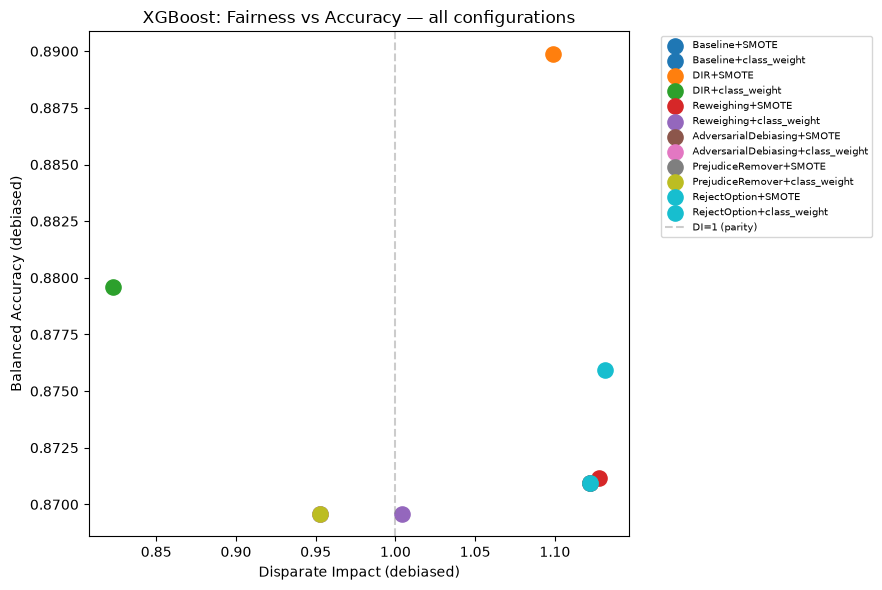

In [18]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(configs)))
for (d, i, _), c in zip(configs, colors):
    row = df_xgb[(df_xgb['Debiasing'] == d) & (df_xgb['Imbalance'] == i)].iloc[0]
    ax.scatter(row['DI (deb)'], row['BA (deb)'], s=120, c=[c], label=f'{d}+{i}')
ax.axvline(1.0, color='gray', ls='--', alpha=0.4, label='DI=1 (parity)')
ax.set_xlabel('Disparate Impact (debiased)')
ax.set_ylabel('Balanced Accuracy (debiased)')
ax.set_title('XGBoost: Fairness vs Accuracy — all configurations')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
